# Pose Trajectory T-CFM Evaluation

Load a trained model checkpoint, generate trajectories conditioned on context vectors, and visualize results.

In [14]:
import os, sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# make sure project root is on path
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ""))
sys.path.insert(0, os.getcwd())
os.chdir(os.path.expanduser("~/PhysicalAI_flowmatching"))

import diffuser.utils as utils

## 1. Configuration

Set the checkpoint path and device. Update `CHECKPOINT_PATH` to point to your trained model.

In [15]:
# --- UPDATE THIS ---
CHECKPOINT_PATH = "logs/pose_trajectory_3D/cfm/H64_T100/20260430-1155/state_192000.pt"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_PATH = "data/pose_traject_dataset_3D.npz"

HORIZON = 64        # padded horizon (must match training)
ORIGINAL_LEN = 50   # original trajectory length
N_SAMPLING_STEPS = 100  # Euler sampling steps for CFM

## 2. Load Dataset

In [16]:
data = np.load(DATA_PATH)
# df = pd.DataFrame(data['features'], columns=data['feature_names'])
df = pd.DataFrame(data['features'], columns=['s_goal_x', 's_goal_y', 's_goal_theta', 'v_const', 'accel', 'q_init_x', 'q_init_y', 'q_init_theta', 'qdot_init_x', 'qdot_init_y', 'qdot_init_theta', 't_init', 'part_enum'])[:1000000]
df['targets'] = [t for t in data['targets']][:1000000]

# Context vector C (9-dim)
part_onehot = pd.get_dummies(df['part_enum'].astype(int), prefix='part').values
C = np.concatenate([
    df[['s_goal_x', 's_goal_y', 's_goal_theta', 'v_const', 'accel']].values,
    # part_onehot,
    df[['q_init_x', 'q_init_y','q_init_theta', 'qdot_init_x', 'qdot_init_y', 'qdot_init_theta']].values
], axis=1)

# Ground truth trajectories (x, y, theta)
targets_raw = np.stack(df['targets'].values)
A_gt = targets_raw[:, :, 0:3]  # (N, 50, 3)

context_all = torch.tensor(C, dtype=torch.float32)
print(f"Dataset: {len(df)} samples, context_dim={C.shape[1]}, trajectory=({A_gt.shape[1]}, {A_gt.shape[2]})")

Dataset: 1000000 samples, context_dim=11, trajectory=(50, 3)


## 3. Build Model & Load Checkpoint

In [17]:
from diffuser.models.temporal_film import ConditionalUnet1D
from diffuser.models.cfm import CFM

observation_dim = 3
action_dim = 0
context_dim = C.shape[1]  # 9

# Build model (must match training config)
model = ConditionalUnet1D(
    horizon=HORIZON,
    transition_dim=observation_dim + action_dim,
    lstm_in_dim=None,
    lstm_out_dim=None,
    global_cond_dim=context_dim,
    cond_dim=observation_dim,
    dim_mults=(1, 4, 8),
).to(DEVICE)

# Build diffusion wrapper
diffusion = CFM(
    model=model,
    horizon=HORIZON,
    observation_dim=observation_dim,
    action_dim=action_dim,
    n_timesteps=N_SAMPLING_STEPS,
    loss_type='l2',
    predict_epsilon=False,
).to(DEVICE)

# Load checkpoint
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
diffusion.load_state_dict(checkpoint['model'])
print(f"Loaded checkpoint from step {checkpoint['step']}")

Loaded checkpoint from step 195000


## 4. Sampling Helper

In [18]:
@torch.no_grad()
def sample_trajectories(diffusion, contexts, n_samples_per=1):
    """
    Generate trajectories for given context vectors.
    
    Args:
        diffusion: trained CFM model
        contexts: (B, context_dim) context tensor
        n_samples_per: how many samples to generate per context
    Returns:
        samples: (B * n_samples_per, ORIGINAL_LEN, 3) numpy array
        contexts_repeated: (B * n_samples_per, context_dim) numpy array
    """
    diffusion.eval()
    
    # repeat contexts for multiple samples
    ctx = contexts.repeat_interleave(n_samples_per, dim=0).to(DEVICE)
    batch_size = ctx.shape[0]
    
    global_cond = {'hideouts': ctx}
    cond = [(np.array([]), np.array([]))] * batch_size
    
    samples = diffusion.conditional_sample(global_cond, cond)  # (B*n, HORIZON, 3)
    samples = samples.cpu().numpy()
    
    # trim padding back to original 50 steps
    samples = samples[:, :ORIGINAL_LEN, :]
    contexts_out = ctx.cpu().numpy()
    
    return samples, contexts_out

print("Sampling helper ready.")

Sampling helper ready.


## 5. Generate Samples & Compute Metrics

Evaluated 200 contexts x 1 samples each
Metric                          Mean        Std     Median
---------------------------------------------------------
XY ADE (best)                 0.0469     0.1265     0.0282
XY ADE (avg)                  0.0469     0.1265     0.0282
XY FDE (best)                 0.0383     0.0332     0.0314
XY FDE (avg)                  0.0383     0.0332     0.0314
Theta ADE (best, rad)         0.0120     0.0144     0.0077
Theta ADE (avg, rad)          0.0120     0.0144     0.0077
Theta FDE (best, rad)         0.0093     0.0073     0.0072
Theta FDE (avg, rad)          0.0093     0.0073     0.0072


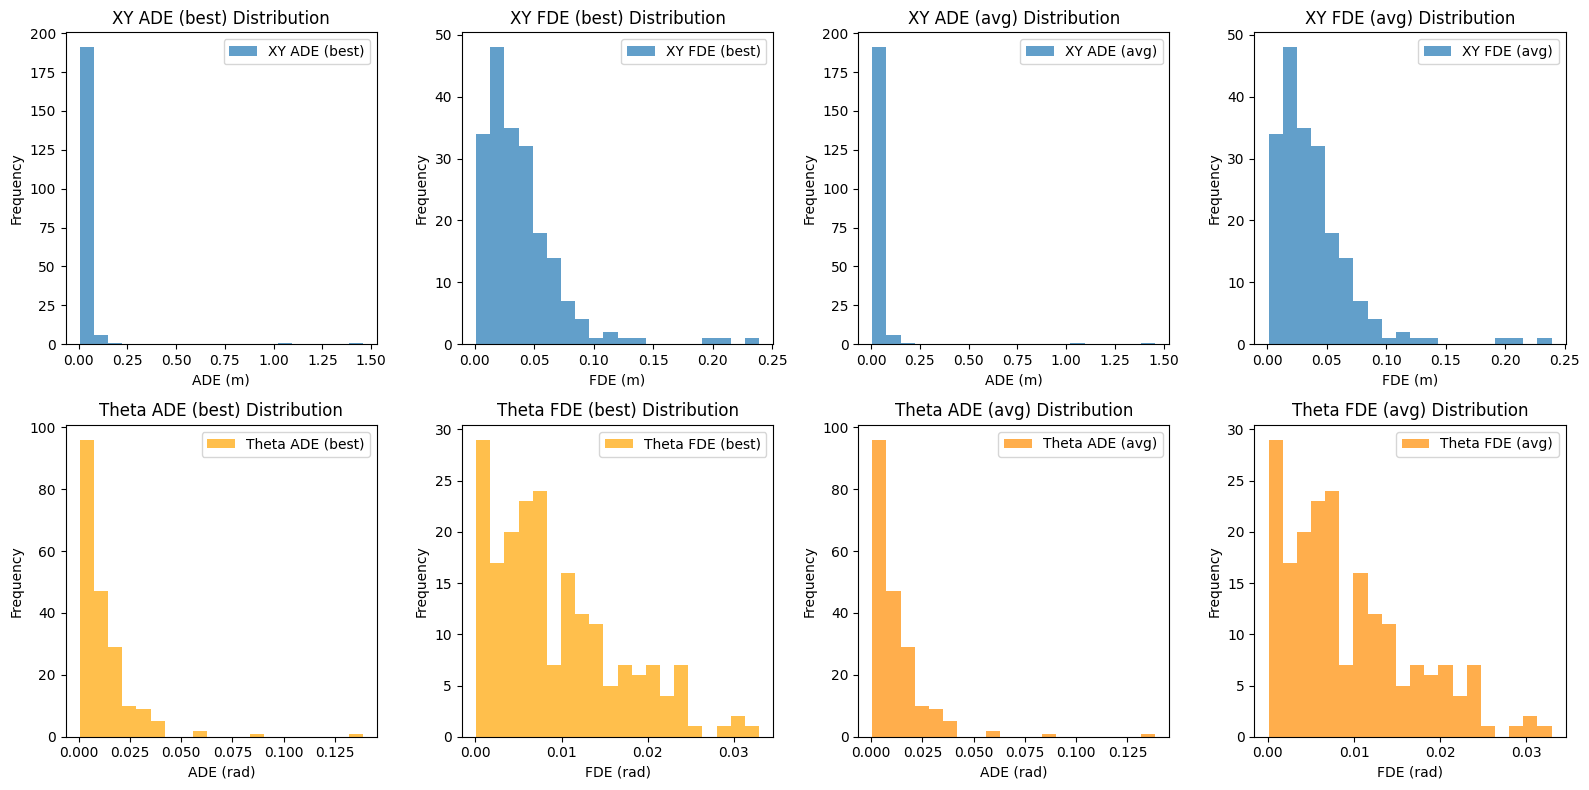

In [19]:
# Pick test samples to evaluate
N_EVAL = 200
N_SAMPLES_PER = 1

rng = np.random.default_rng(42)
eval_idx = rng.choice(len(context_all), N_EVAL, replace=False)

eval_contexts = context_all[eval_idx]
eval_gt = A_gt[eval_idx]  # (N_EVAL, 50, 3)

# Generate
samples, _ = sample_trajectories(diffusion, eval_contexts, n_samples_per=N_SAMPLES_PER)
samples = samples.reshape(N_EVAL, N_SAMPLES_PER, ORIGINAL_LEN, 3)

# --- Positional ADE/FDE (x, y only) ---
xy_samples = samples[:, :, :, :2]
xy_gt = eval_gt[:, None, :, :2]
ade_per_sample = np.sqrt(((xy_samples - xy_gt) ** 2).sum(axis=-1)).mean(axis=-1)  # (N_EVAL, N_SAMPLES_PER)
ade_min = ade_per_sample.min(axis=1)
ade_mean = ade_per_sample.mean(axis=1)

fde_per_sample = np.sqrt(((xy_samples[:, :, -1, :] - eval_gt[:, None, -1, :2]) ** 2).sum(axis=-1))
fde_min = fde_per_sample.min(axis=1)
fde_mean = fde_per_sample.mean(axis=1)

# --- Theta ADE/FDE (wrapped angle error) ---
def angle_diff(a, b):
    """Wrapped angle difference a - b in [-pi, pi]."""
    return np.arctan2(np.sin(a - b), np.cos(a - b))

theta_samples = samples[:, :, :, 2]
theta_gt = eval_gt[:, :, 2]
theta_err = np.abs(angle_diff(theta_samples, theta_gt[:, None, :]))  # (N_EVAL, N_SAMPLES_PER, 50)
theta_ade_per_sample = theta_err.mean(axis=-1)
theta_ade_min = theta_ade_per_sample.min(axis=1)
theta_ade_mean = theta_ade_per_sample.mean(axis=1)

theta_fde_per_sample = np.abs(angle_diff(theta_samples[:, :, -1], theta_gt[:, None, -1]))
theta_fde_min = theta_fde_per_sample.min(axis=1)
theta_fde_mean = theta_fde_per_sample.mean(axis=1)

print(f"Evaluated {N_EVAL} contexts x {N_SAMPLES_PER} samples each")
print(f"{'Metric':<25} {'Mean':>10} {'Std':>10} {'Median':>10}")
print("-" * 57)
print(f"{'XY ADE (best)':<25} {ade_min.mean():>10.4f} {ade_min.std():>10.4f} {np.median(ade_min):>10.4f}")
print(f"{'XY ADE (avg)':<25} {ade_mean.mean():>10.4f} {ade_mean.std():>10.4f} {np.median(ade_mean):>10.4f}")
print(f"{'XY FDE (best)':<25} {fde_min.mean():>10.4f} {fde_min.std():>10.4f} {np.median(fde_min):>10.4f}")
print(f"{'XY FDE (avg)':<25} {fde_mean.mean():>10.4f} {fde_mean.std():>10.4f} {np.median(fde_mean):>10.4f}")
print(f"{'Theta ADE (best, rad)':<25} {theta_ade_min.mean():>10.4f} {theta_ade_min.std():>10.4f} {np.median(theta_ade_min):>10.4f}")
print(f"{'Theta ADE (avg, rad)':<25} {theta_ade_mean.mean():>10.4f} {theta_ade_mean.std():>10.4f} {np.median(theta_ade_mean):>10.4f}")
print(f"{'Theta FDE (best, rad)':<25} {theta_fde_min.mean():>10.4f} {theta_fde_min.std():>10.4f} {np.median(theta_fde_min):>10.4f}")
print(f"{'Theta FDE (avg, rad)':<25} {theta_fde_mean.mean():>10.4f} {theta_fde_mean.std():>10.4f} {np.median(theta_fde_mean):>10.4f}")

# plot distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Row 1: XY metrics
axes[0, 0].hist(ade_min, bins=20, alpha=0.7, label='XY ADE (best)')
axes[0, 0].set_xlabel('ADE (m)'); axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('XY ADE (best) Distribution'); axes[0, 0].legend()

axes[0, 1].hist(fde_min, bins=20, alpha=0.7, label='XY FDE (best)')
axes[0, 1].set_xlabel('FDE (m)'); axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('XY FDE (best) Distribution'); axes[0, 1].legend()

axes[0, 2].hist(ade_mean, bins=20, alpha=0.7, label='XY ADE (avg)')
axes[0, 2].set_xlabel('ADE (m)'); axes[0, 2].set_ylabel('Frequency')
axes[0, 2].set_title('XY ADE (avg) Distribution'); axes[0, 2].legend()

axes[0, 3].hist(fde_mean, bins=20, alpha=0.7, label='XY FDE (avg)')
axes[0, 3].set_xlabel('FDE (m)'); axes[0, 3].set_ylabel('Frequency')
axes[0, 3].set_title('XY FDE (avg) Distribution'); axes[0, 3].legend()

# Row 2: Theta metrics
axes[1, 0].hist(theta_ade_min, bins=20, alpha=0.7, color='orange', label='Theta ADE (best)')
axes[1, 0].set_xlabel('ADE (rad)'); axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Theta ADE (best) Distribution'); axes[1, 0].legend()

axes[1, 1].hist(theta_fde_min, bins=20, alpha=0.7, color='orange', label='Theta FDE (best)')
axes[1, 1].set_xlabel('FDE (rad)'); axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Theta FDE (best) Distribution'); axes[1, 1].legend()

axes[1, 2].hist(theta_ade_mean, bins=20, alpha=0.7, color='darkorange', label='Theta ADE (avg)')
axes[1, 2].set_xlabel('ADE (rad)'); axes[1, 2].set_ylabel('Frequency')
axes[1, 2].set_title('Theta ADE (avg) Distribution'); axes[1, 2].legend()

axes[1, 3].hist(theta_fde_mean, bins=20, alpha=0.7, color='darkorange', label='Theta FDE (avg)')
axes[1, 3].set_xlabel('FDE (rad)'); axes[1, 3].set_ylabel('Frequency')
axes[1, 3].set_title('Theta FDE (avg) Distribution'); axes[1, 3].legend()

plt.tight_layout()
plt.show()

## 6. Plot: Generated vs Ground Truth Trajectories

Each subplot shows one test context. The ground truth is in black, and generated samples are colored.

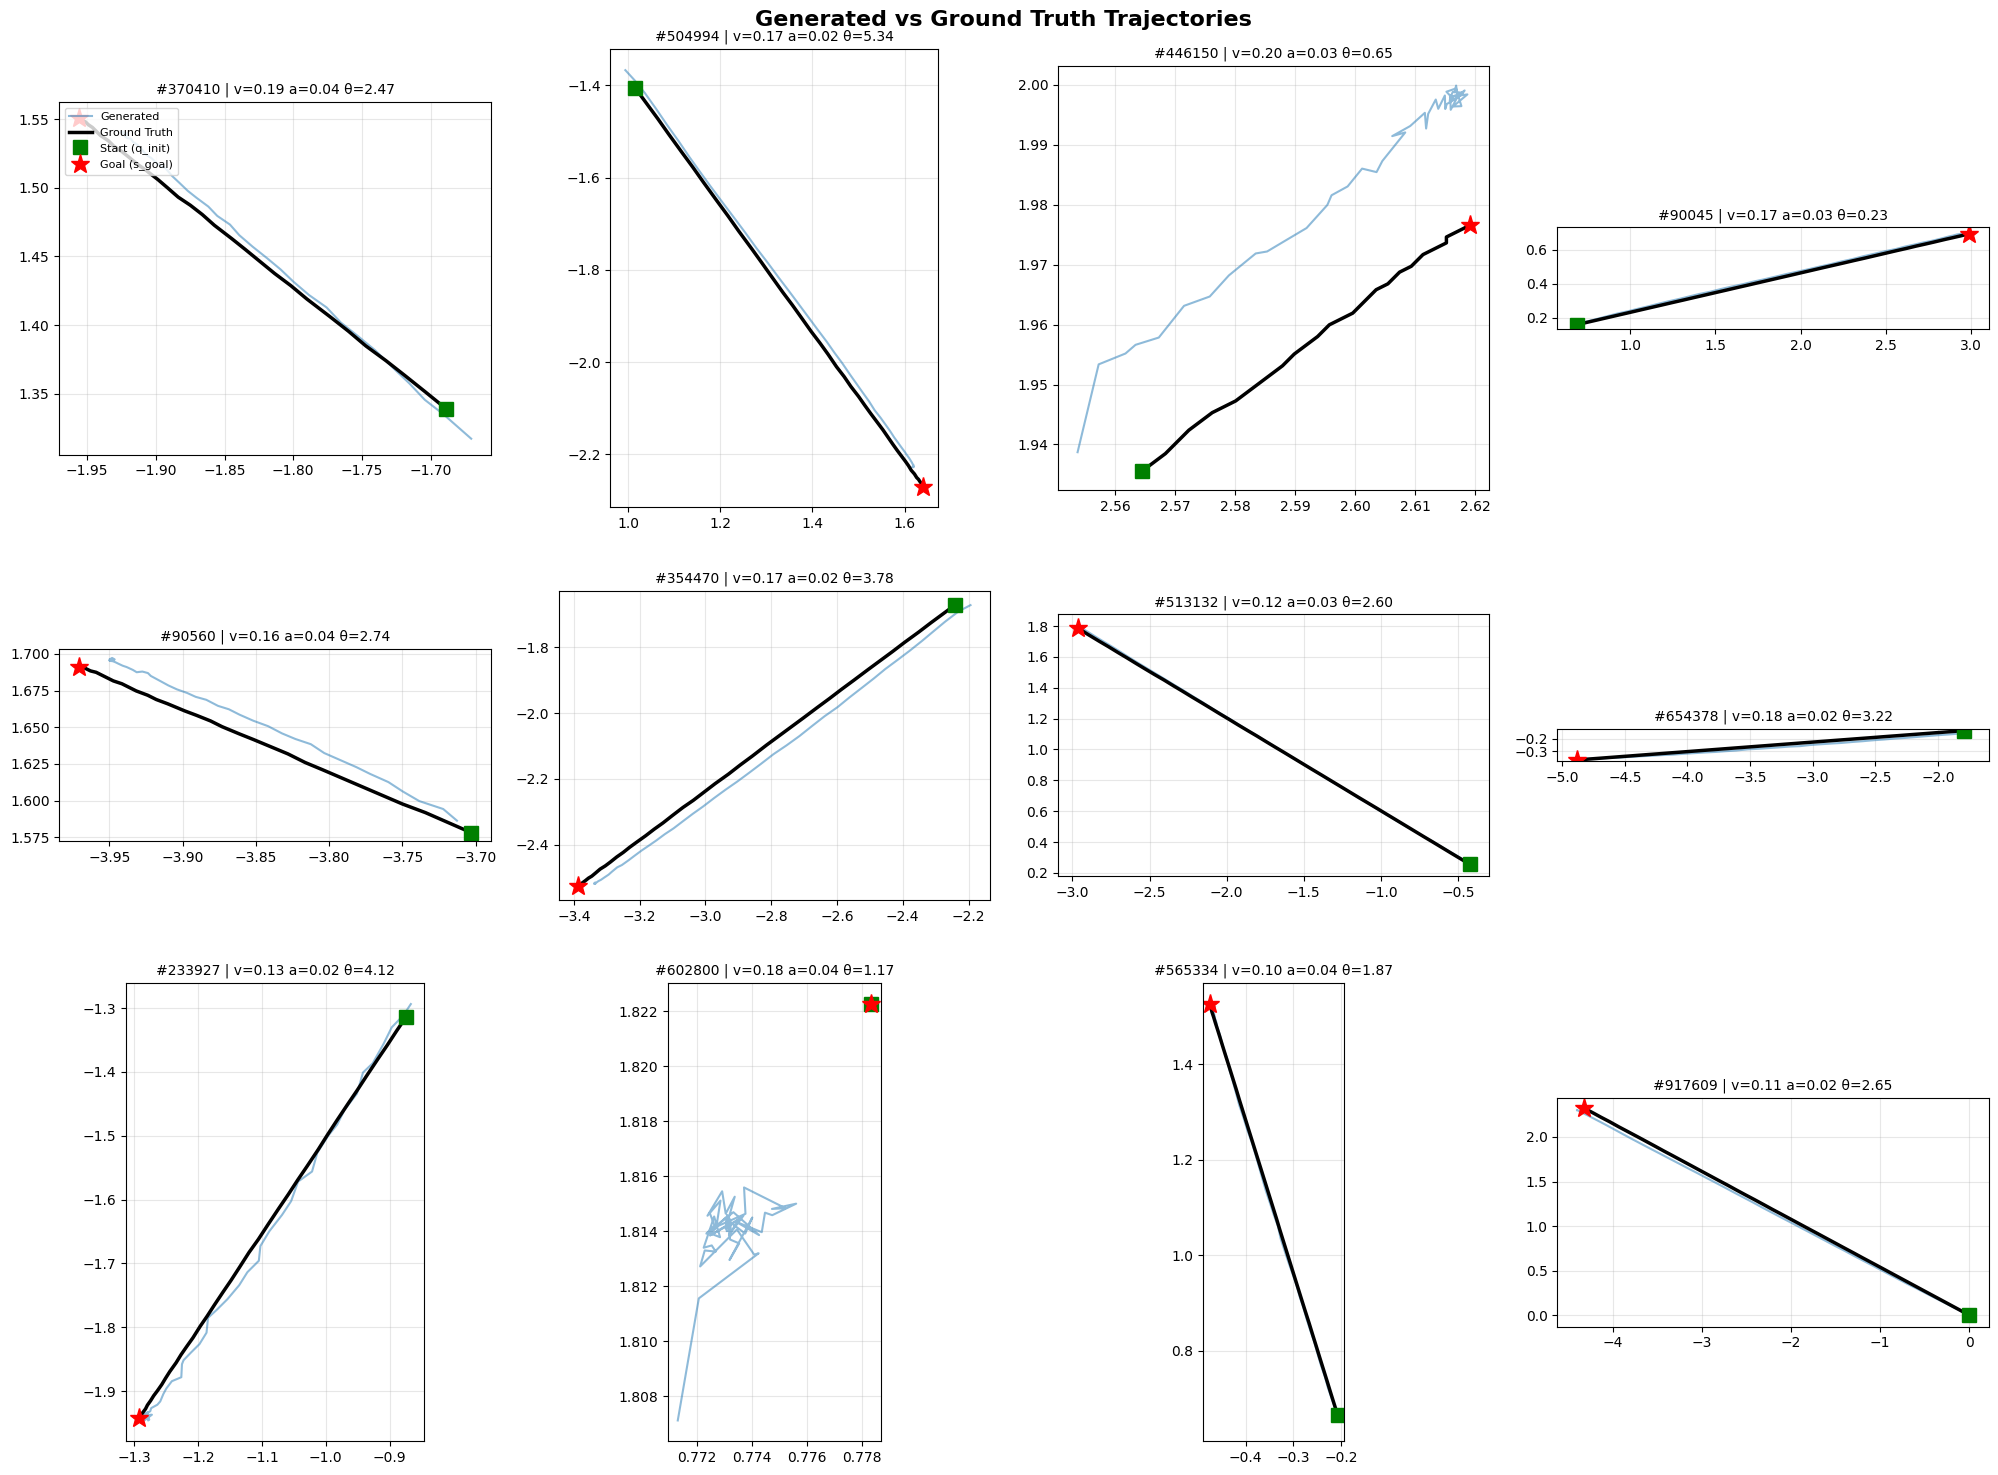

In [20]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, ax in enumerate(axes):
    gt = eval_gt[i]  # (50, 3)
    ctx = eval_contexts[i].numpy()
    
    # plot generated samples
    for s in range(N_SAMPLES_PER):
        traj = samples[i, s]  # (50, 3)
        ax.plot(traj[:, 0], traj[:, 1], alpha=0.5, linewidth=1.5, label='Generated' if s == 0 else None)
    
    # plot ground truth
    ax.plot(gt[:, 0], gt[:, 1], 'k-', linewidth=2.5, label='Ground Truth')
    
    # ctx: [s_goal_x, s_goal_y, s_goal_theta, v_const, accel, q_init_x, q_init_y, q_init_theta, ...]
    ax.plot(ctx[5], ctx[6], 'gs', markersize=10, label='Start (q_init)')
    ax.plot(ctx[0], ctx[1], 'r*', markersize=14, label='Goal (s_goal)')
    
    ax.set_title(f"#{eval_idx[i]} | v={ctx[3]:.2f} a={ctx[4]:.2f} θ={ctx[2]:.2f}", fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    
    if i == 0:
        ax.legend(fontsize=8, loc='upper left')

plt.suptitle("Generated vs Ground Truth Trajectories", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 6b. Plot: x(t) and y(t) Over Time (GT vs Generated)

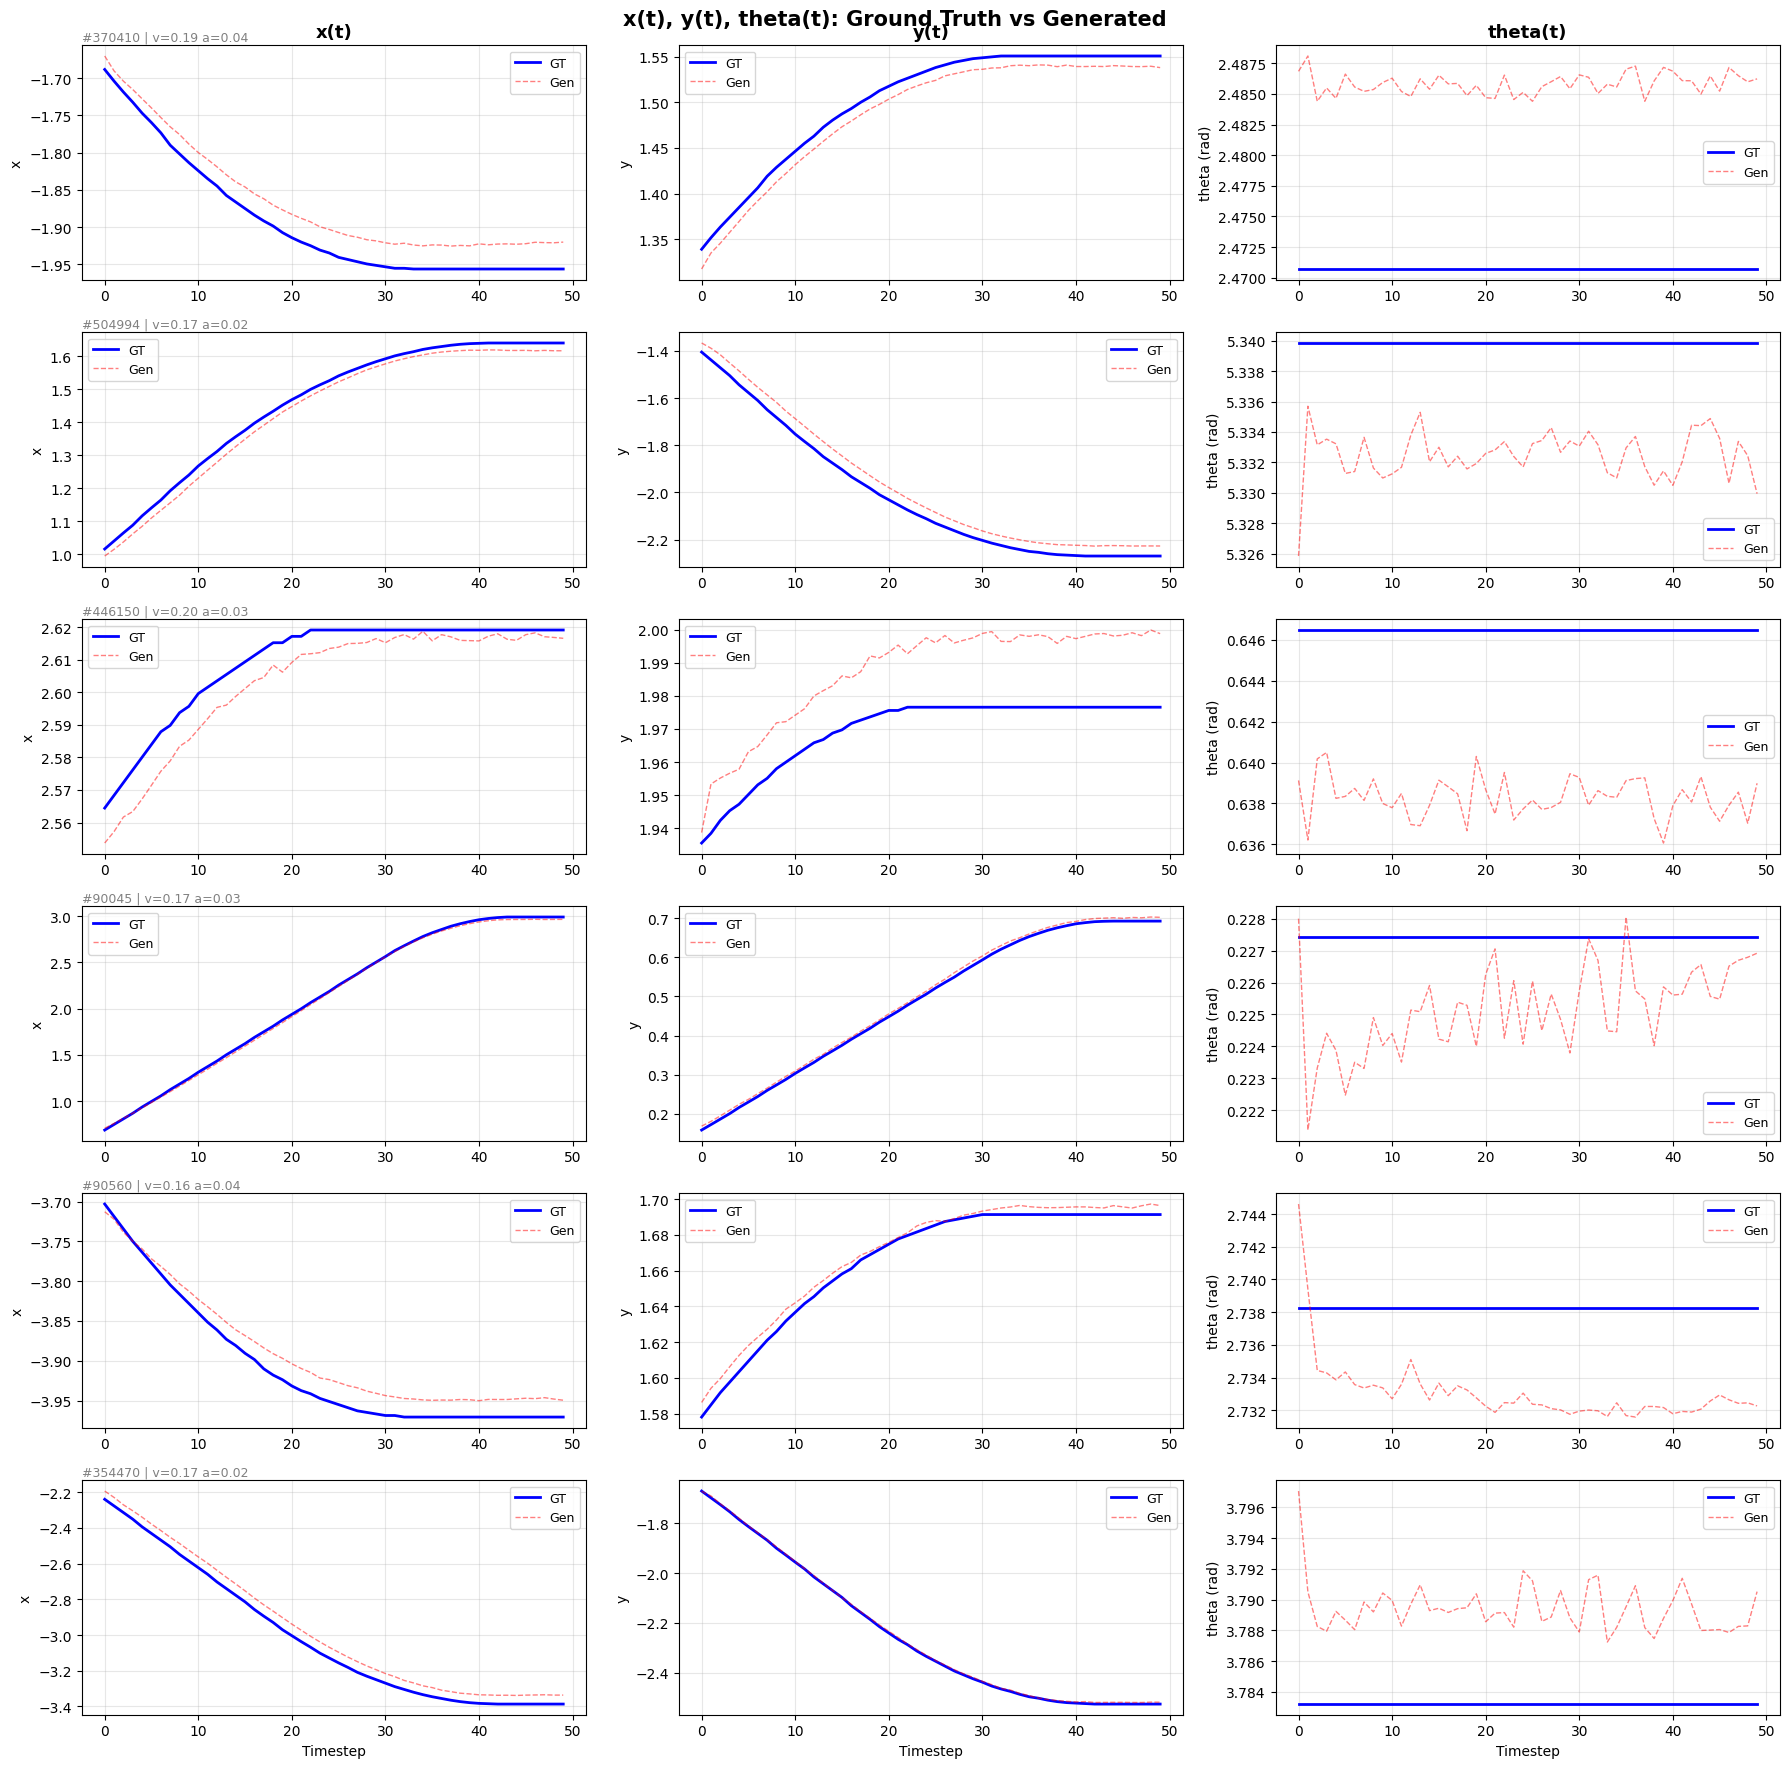

In [21]:
N_SHOW = 6  # number of examples to plot

fig, axes = plt.subplots(N_SHOW, 3, figsize=(18, 3 * N_SHOW))
timesteps = np.arange(ORIGINAL_LEN)

for i in range(N_SHOW):
    gt = eval_gt[i]          # (50, 3)
    gen = samples[i, 0]      # (50, 3) — first sample

    # x(t)
    ax_x = axes[i, 0]
    ax_x.plot(timesteps, gt[:, 0], 'b-', linewidth=2, label='GT')
    for s in range(N_SAMPLES_PER):
        ax_x.plot(timesteps, samples[i, s, :, 0], 'r--', linewidth=1, alpha=0.5,
                  label='Gen' if s == 0 else None)
    ax_x.set_ylabel('x')
    ax_x.grid(True, alpha=0.3)
    ax_x.legend(fontsize=9)
    if i == 0:
        ax_x.set_title('x(t)', fontsize=13, fontweight='bold')
    if i == N_SHOW - 1:
        ax_x.set_xlabel('Timestep')

    # y(t)
    ax_y = axes[i, 1]
    ax_y.plot(timesteps, gt[:, 1], 'b-', linewidth=2, label='GT')
    for s in range(N_SAMPLES_PER):
        ax_y.plot(timesteps, samples[i, s, :, 1], 'r--', linewidth=1, alpha=0.5,
                  label='Gen' if s == 0 else None)
    ax_y.set_ylabel('y')
    ax_y.grid(True, alpha=0.3)
    ax_y.legend(fontsize=9)
    if i == 0:
        ax_y.set_title('y(t)', fontsize=13, fontweight='bold')
    if i == N_SHOW - 1:
        ax_y.set_xlabel('Timestep')

    # theta(t)
    ax_t = axes[i, 2]
    ax_t.plot(timesteps, gt[:, 2], 'b-', linewidth=2, label='GT')
    for s in range(N_SAMPLES_PER):
        ax_t.plot(timesteps, samples[i, s, :, 2], 'r--', linewidth=1, alpha=0.5,
                  label='Gen' if s == 0 else None)
    ax_t.set_ylabel('theta (rad)')
    ax_t.grid(True, alpha=0.3)
    ax_t.legend(fontsize=9)
    if i == 0:
        ax_t.set_title('theta(t)', fontsize=13, fontweight='bold')
    if i == N_SHOW - 1:
        ax_t.set_xlabel('Timestep')

    # label each row
    ctx = eval_contexts[i].numpy()
    axes[i, 0].annotate(f'#{eval_idx[i]} | v={ctx[3]:.2f} a={ctx[4]:.2f}',
                         xy=(0, 1.02), xycoords='axes fraction', fontsize=9, color='gray')

plt.suptitle('x(t), y(t), theta(t): Ground Truth vs Generated', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Plot: ADE Over Prediction Horizon

Shows how error accumulates over time (per-timestep displacement error).

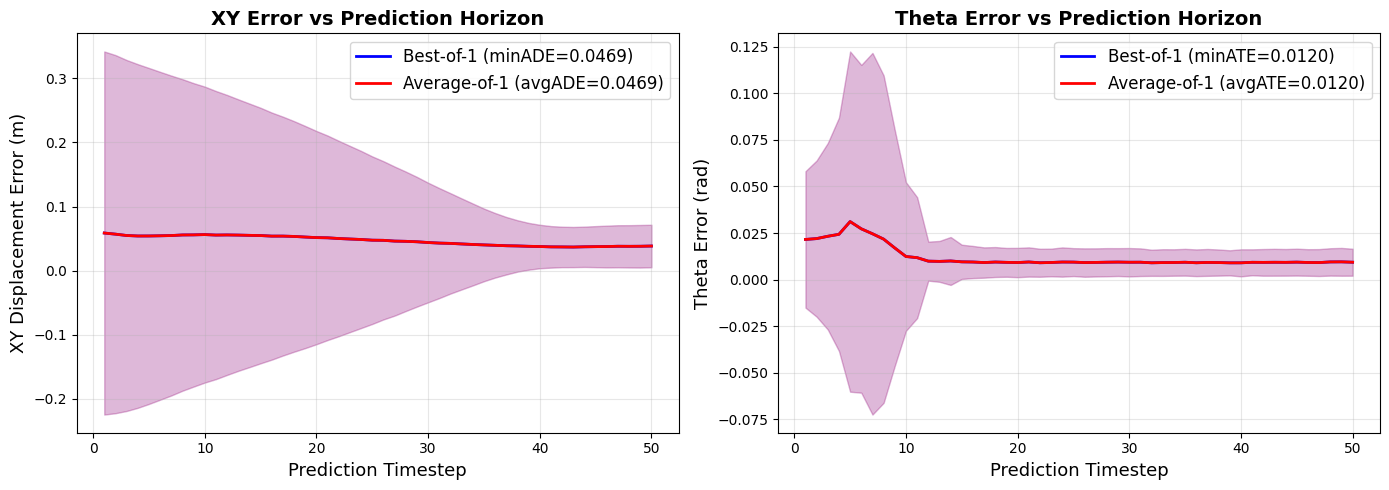

In [22]:
# Per-timestep XY displacement error: (N_EVAL, N_SAMPLES_PER, 50)
de_per_step = np.sqrt(((samples[:, :, :, :2] - eval_gt[:, None, :, :2]) ** 2).sum(axis=-1))

# Per-timestep theta error (wrapped): (N_EVAL, N_SAMPLES_PER, 50)
theta_de_per_step = np.abs(angle_diff(samples[:, :, :, 2], eval_gt[:, None, :, 2]))

# Best-of-N: pick the sample with lowest ADE for each context
best_idx = ade_per_sample.argmin(axis=1)  # (N_EVAL,)
de_best = de_per_step[np.arange(N_EVAL), best_idx, :]         # (N_EVAL, 50)
de_avg = de_per_step.mean(axis=1)                              # (N_EVAL, 50)
theta_de_best = theta_de_per_step[np.arange(N_EVAL), best_idx, :]
theta_de_avg = theta_de_per_step.mean(axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
timesteps = np.arange(1, ORIGINAL_LEN + 1)

# XY positional error
mean_best = de_best.mean(axis=0)
std_best = de_best.std(axis=0)
mean_avg = de_avg.mean(axis=0)
std_avg = de_avg.std(axis=0)

ax1.plot(timesteps, mean_best, 'b-', linewidth=2, label=f'Best-of-{N_SAMPLES_PER} (minADE={mean_best.mean():.4f})')
ax1.fill_between(timesteps, mean_best - std_best, mean_best + std_best, alpha=0.15, color='b')
ax1.plot(timesteps, mean_avg, 'r-', linewidth=2, label=f'Average-of-{N_SAMPLES_PER} (avgADE={mean_avg.mean():.4f})')
ax1.fill_between(timesteps, mean_avg - std_avg, mean_avg + std_avg, alpha=0.15, color='r')
ax1.set_xlabel("Prediction Timestep", fontsize=13)
ax1.set_ylabel("XY Displacement Error (m)", fontsize=13)
ax1.set_title("XY Error vs Prediction Horizon", fontsize=14, fontweight='bold')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Theta error
mean_theta_best = theta_de_best.mean(axis=0)
std_theta_best = theta_de_best.std(axis=0)
mean_theta_avg = theta_de_avg.mean(axis=0)
std_theta_avg = theta_de_avg.std(axis=0)

ax2.plot(timesteps, mean_theta_best, 'b-', linewidth=2, label=f'Best-of-{N_SAMPLES_PER} (minATE={mean_theta_best.mean():.4f})')
ax2.fill_between(timesteps, mean_theta_best - std_theta_best, mean_theta_best + std_theta_best, alpha=0.15, color='b')
ax2.plot(timesteps, mean_theta_avg, 'r-', linewidth=2, label=f'Average-of-{N_SAMPLES_PER} (avgATE={mean_theta_avg.mean():.4f})')
ax2.fill_between(timesteps, mean_theta_avg - std_theta_avg, mean_theta_avg + std_theta_avg, alpha=0.15, color='r')
ax2.set_xlabel("Prediction Timestep", fontsize=13)
ax2.set_ylabel("Theta Error (rad)", fontsize=13)
ax2.set_title("Theta Error vs Prediction Horizon", fontsize=14, fontweight='bold')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Plot: ADE Distribution & Per-Part Breakdown

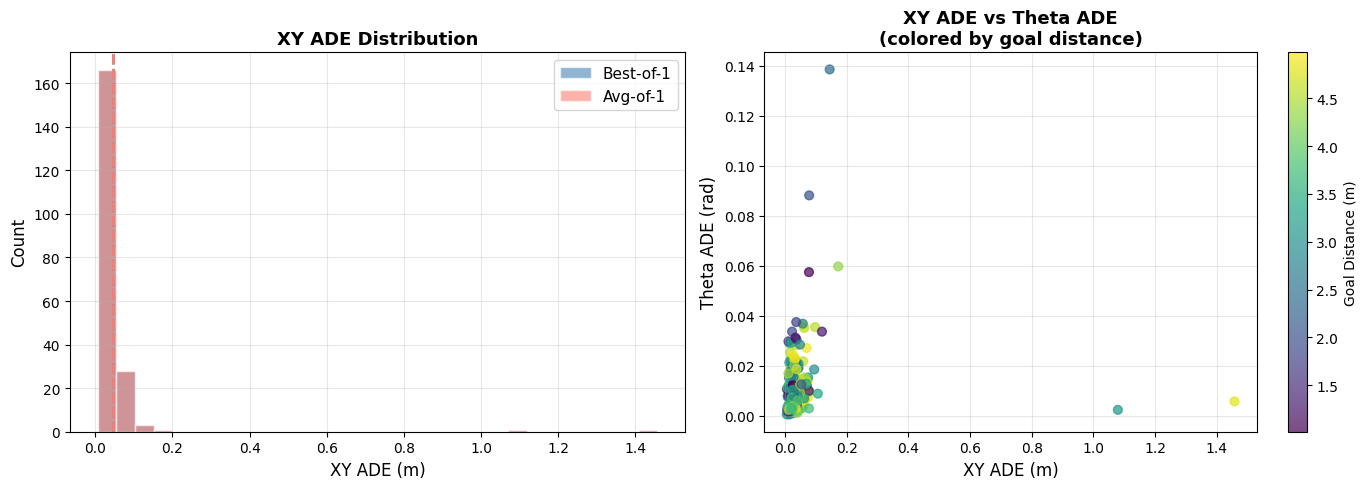

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: XY ADE histogram ---
ax1.hist(ade_min, bins=30, alpha=0.6, label=f'Best-of-{N_SAMPLES_PER}', color='steelblue', edgecolor='white')
ax1.hist(ade_mean, bins=30, alpha=0.6, label=f'Avg-of-{N_SAMPLES_PER}', color='salmon', edgecolor='white')
ax1.axvline(ade_min.mean(), color='steelblue', linestyle='--', linewidth=2)
ax1.axvline(ade_mean.mean(), color='salmon', linestyle='--', linewidth=2)
ax1.set_xlabel("XY ADE (m)", fontsize=12)
ax1.set_ylabel("Count", fontsize=12)
ax1.set_title("XY ADE Distribution", fontsize=13, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# --- Right: XY ADE vs Theta ADE scatter (colored by goal distance) ---
eval_ctx_np = eval_contexts.numpy()
goal_dist = np.sqrt(eval_ctx_np[:, 0]**2 + eval_ctx_np[:, 1]**2)

sc = ax2.scatter(ade_min, theta_ade_min, c=goal_dist, cmap='viridis', alpha=0.7, s=40)
plt.colorbar(sc, ax=ax2, label='Goal Distance (m)')
ax2.set_xlabel("XY ADE (m)", fontsize=12)
ax2.set_ylabel("Theta ADE (rad)", fontsize=12)
ax2.set_title("XY ADE vs Theta ADE\n(colored by goal distance)", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Plot: Multimodality Check

For a single context, generate many samples to see if the model captures diverse trajectories.

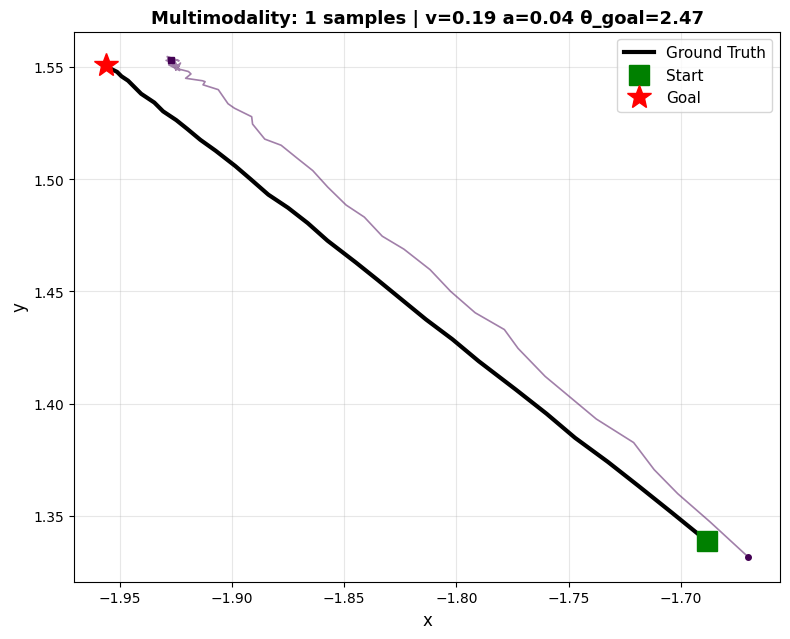

In [26]:
N_MULTI = 1  # generate 20 samples for a single context
pick = 0      # which eval sample to use

single_ctx = eval_contexts[pick:pick+1]
multi_samples, _ = sample_trajectories(diffusion, single_ctx, n_samples_per=N_MULTI)
# multi_samples: (N_MULTI, 50, 3)

fig, ax = plt.subplots(figsize=(8, 8))
cmap = plt.cm.viridis

for s in range(N_MULTI):
    traj = multi_samples[s]
    color = cmap(s / N_MULTI)
    ax.plot(traj[:, 0], traj[:, 1], alpha=0.5, linewidth=1.2, color=color)
    ax.plot(traj[0, 0], traj[0, 1], 'o', color=color, markersize=4)
    ax.plot(traj[-1, 0], traj[-1, 1], 's', color=color, markersize=4)

# Ground truth
gt = eval_gt[pick]
ax.plot(gt[:, 0], gt[:, 1], 'k-', linewidth=3, label='Ground Truth')

# ctx: [s_goal_x, s_goal_y, s_goal_theta, v_const, accel, q_init_x, q_init_y, ...]
ctx = single_ctx.numpy()[0]
ax.plot(ctx[5], ctx[6], 'gs', markersize=14, zorder=5, label='Start')
ax.plot(ctx[0], ctx[1], 'r*', markersize=18, zorder=5, label='Goal')

ax.set_title(f"Multimodality: {N_MULTI} samples | v={ctx[3]:.2f} a={ctx[4]:.2f} θ_goal={ctx[2]:.2f}",
             fontsize=13, fontweight='bold')
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("y", fontsize=12)
ax.set_aspect('equal')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Plot: Sampling Speed vs Quality (N steps)

Test how many Euler steps are needed for good quality (like Fig. 4b in the paper).

  N=  1 steps | XY ADE=0.0481 | Time=0.01s
  N=  2 steps | XY ADE=0.0264 | Time=0.01s
  N=  5 steps | XY ADE=0.0271 | Time=0.02s
  N= 10 steps | XY ADE=0.0284 | Time=0.03s
  N= 25 steps | XY ADE=0.0393 | Time=0.09s
  N= 50 steps | XY ADE=0.0326 | Time=0.16s
  N=100 steps | XY ADE=0.0396 | Time=0.32s


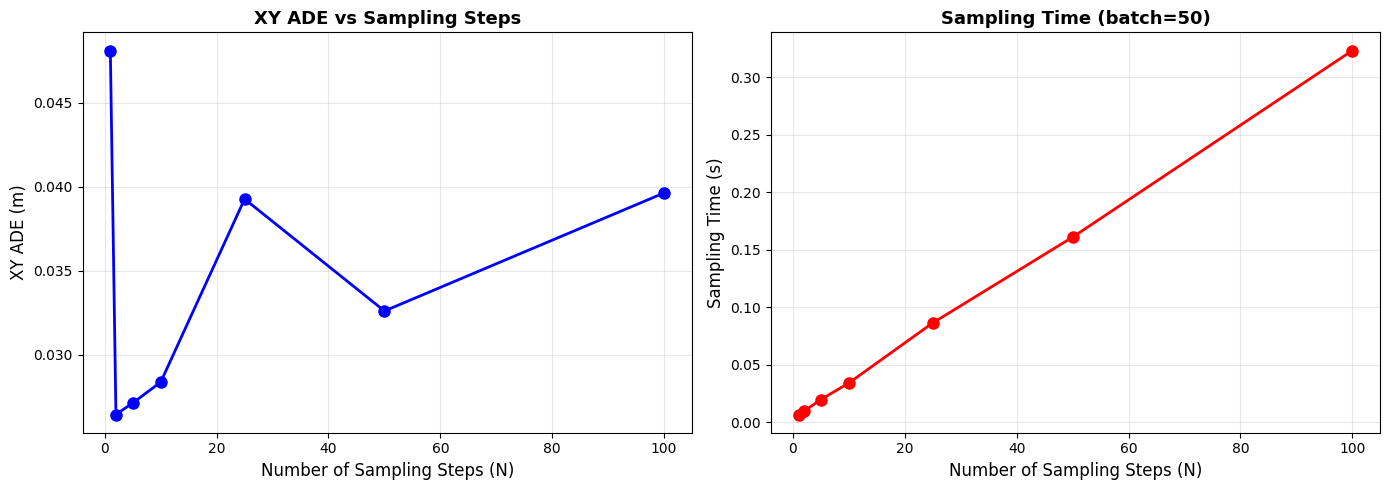

In [27]:
import time

step_counts = [1, 2, 5, 10, 25, 50, 100]
ade_by_steps = []
times_by_steps = []

# Use a small batch for speed test
speed_ctx = eval_contexts[:50]
speed_gt = eval_gt[:50]

for n_steps in step_counts:
    diffusion.set_sampling_timesteps(n_steps)
    
    t0 = time.time()
    samp, _ = sample_trajectories(diffusion, speed_ctx, n_samples_per=1)
    elapsed = time.time() - t0
    
    # XY positional error only
    ade = np.sqrt(((samp[:, :, :2] - speed_gt[:, :, :2]) ** 2).sum(axis=-1)).mean()
    ade_by_steps.append(ade)
    times_by_steps.append(elapsed)
    print(f"  N={n_steps:>3d} steps | XY ADE={ade:.4f} | Time={elapsed:.2f}s")

# Reset to default
diffusion.set_sampling_timesteps(N_SAMPLING_STEPS)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(step_counts, ade_by_steps, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel("Number of Sampling Steps (N)", fontsize=12)
ax1.set_ylabel("XY ADE (m)", fontsize=12)
ax1.set_title("XY ADE vs Sampling Steps", fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2.plot(step_counts, times_by_steps, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel("Number of Sampling Steps (N)", fontsize=12)
ax2.set_ylabel("Sampling Time (s)", fontsize=12)
ax2.set_title(f"Sampling Time (batch={len(speed_ctx)})", fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()